# Experiment 1 — Layout Comparison: Contiguous vs Paged KV Cache

**Research question (Exp 1):** Where is the *crossover point* at which a paged KV cache starts to
outperform a contiguous KV cache on **throughput**, holding `block_size = 16` (vLLM default) and
FP16 page storage constant?

**Hypothesis H1 (regime-dependent crossover).** Paged beats contiguous on throughput and memory at
`seq_len >= 512` **and** `batch_size >= 4`, but *underperforms* at short sequences because block-table
lookups add per-token (TPOT) overhead.

This notebook reports four things, in order:
1. **Decode latency (TPOT)** — does paged's per-token cost stay flat as context grows? (regression check)
2. **Throughput crossover (H1)** — the headline: a paged/contiguous ratio map + Figure 1 heatmap.
3. **OOM / degraded runs** — OOM is a *data point*, not a failure.
4. **Memory & fragmentation** — the structural difference between the two layouts.

> Methodology note: numbers are medians over 5 measured runs after 3 warm-ups, on CUDA. Paged stores
> FP16 pages while contiguous matches the model dtype, so absolute latencies carry a small precision
> caveat — trends and crossovers are the point, not the third decimal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

# --- locate experiments/results no matter where the kernel started ---
def find_results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / 'experiments' / 'results'
        if cand.exists():
            return cand
    raise FileNotFoundError('Could not find experiments/results from ' + str(Path.cwd()))

RESULTS = find_results_dir()
# Use the most recent layout-comparison CSV (…2 is the latest paged.py rewrite).
CSV = sorted(RESULTS.glob('exp1_layout_comparison*.csv'))[-1]
print('Loading:', CSV.name)

df = pd.read_csv(CSV)

# --- robustly handle OOM rows: the spec logs OOM as the metric value ---
NUM_COLS = ['ttft_ms', 'tpot_ms', 'throughput', 'memory_mb', 'frag_ratio']
df['is_oom'] = df[NUM_COLS].astype(str).apply(lambda s: s.str.upper() == 'OOM').any(axis=1)
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

ok = df[~df['is_oom']].copy()
print(f'{len(df)} rows  |  {df["is_oom"].sum()} OOM  |  cache types: {sorted(df.cache_type.unique())}')
print(f'seq_len: {sorted(ok.seq_len.unique())}   batch: {sorted(ok.batch.unique())}')
df.head()

Loading: exp1_layout_comparison2.csv
40 rows  |  0 OOM  |  cache types: ['contiguous', 'paged']
seq_len: [np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]   batch: [np.int64(1), np.int64(4), np.int64(8), np.int64(16)]


,cache_type,seq_len,batch,block_size,ttft_ms,tpot_ms,throughput,memory_mb,frag_ratio,is_oom
0,contiguous,128,1,NaN,4.502,3.584,267.7,147.63,0.0,False
1,contiguous,128,4,NaN,6.361,2.789,1359.7,226.45,0.0,False
2,contiguous,128,8,NaN,6.164,3.068,2448.0,332.21,0.0,False
3,contiguous,128,16,NaN,10.082,4.053,3733.9,541.70,0.0,False
4,contiguous,256,1,NaN,3.968,2.091,453.4,174.48,0.0,False


## 1. Decode latency (TPOT) — does paged stay flat as context grows?

The failure mode we are guarding against: an implementation that **re-materialises the whole cache
every decode step** makes paged TPOT climb linearly with `seq_len`. A healthy cache keeps TPOT roughly
*flat* in `seq_len` (attention compute grows, but the cache bookkeeping should not dominate).

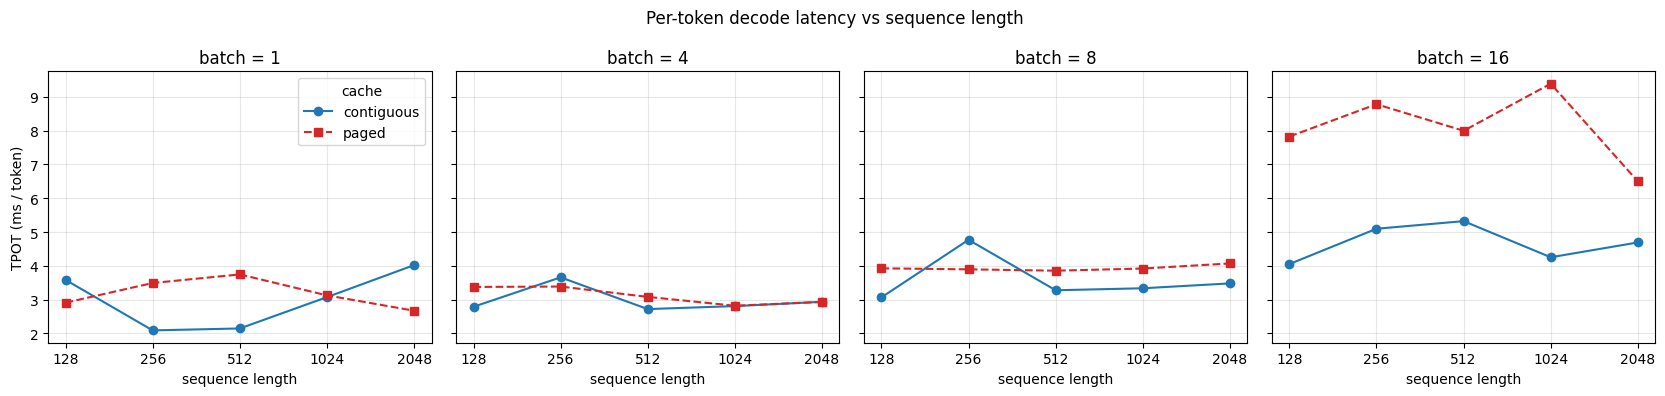

Paged TPOT growth (longest seq / shortest seq), per batch — ~1.0 means flat:
  batch  1: 0.92x  (2.91 -> 2.67 ms)
  batch  4: 0.87x  (3.38 -> 2.93 ms)
  batch  8: 1.04x  (3.93 -> 4.07 ms)
  batch 16: 0.83x  (7.83 -> 6.50 ms)


In [2]:
# Grayscale-safe styles: distinguish by BOTH colour and line style (paper requirement).
STYLE = {
    'contiguous': dict(color='#1f77b4', linestyle='-',  marker='o'),
    'paged':      dict(color='#d62728', linestyle='--', marker='s'),
}

batches = sorted(ok['batch'].unique())
fig, axes = plt.subplots(1, len(batches), figsize=(4.2 * len(batches), 4), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, batch in zip(axes, batches):
    sub = ok[ok['batch'] == batch]
    for ct in ['contiguous', 'paged']:
        cs = sub[sub['cache_type'] == ct].sort_values('seq_len')
        ax.plot(cs['seq_len'], cs['tpot_ms'], label=ct, **STYLE[ct])
    ax.set_title(f'batch = {batch}')
    ax.set_xlabel('sequence length')
    ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(ok.seq_len.unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('TPOT (ms / token)')
axes[0].legend(title='cache')
fig.suptitle('Per-token decode latency vs sequence length')
fig.tight_layout()
plt.show()

# Quantify 'flatness': how much does paged TPOT grow from shortest to longest seq, per batch?
print('Paged TPOT growth (longest seq / shortest seq), per batch — ~1.0 means flat:')
for batch in batches:
    p = ok[(ok.cache_type == 'paged') & (ok.batch == batch)].sort_values('seq_len')
    if len(p) >= 2:
        print(f'  batch {batch:>2}: {p.tpot_ms.iloc[-1] / p.tpot_ms.iloc[0]:.2f}x'
              f'  ({p.tpot_ms.iloc[0]:.2f} -> {p.tpot_ms.iloc[-1]:.2f} ms)')

## 2. Throughput crossover (H1) — the headline

For every `(batch, seq_len)` cell we compute **ratio = throughput(paged) / throughput(contiguous)**.
A value **> 1.0 means paged wins**. We then test H1 directly: does paged win across the whole
`seq_len >= 512` **and** `batch >= 4` block?

In [8]:
def matrix(metric, cache):
    """rows = batch, cols = seq_len."""
    return (ok[ok.cache_type == cache]
            .pivot_table(index='batch', columns='seq_len', values=metric)
            .sort_index().sort_index(axis=1))

thr_p, thr_c = matrix('throughput', 'paged'), matrix('throughput', 'contiguous')
ratio = thr_p / thr_c

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print('Throughput ratio  paged / contiguous   (>1.00 = paged wins)\n')
print(ratio.to_string())

# Where does paged win?
wins = [(b, s, ratio.loc[b, s]) for b in ratio.index for s in ratio.columns
        if pd.notna(ratio.loc[b, s]) and ratio.loc[b, s] > 1.0]
if wins:
    print('\nPaged WINS in these regimes:')
    for b, s, r in sorted(wins, key=lambda t: -t[2]):
        print(f'  seq={s:>4}  batch={b:>2}  ->  {r:.2f}x')
else:
    print('\n>>> No regime where paged beats contiguous on throughput.')

# Direct H1 test: seq_len >= 512 AND batch >= 4
h1_cols = [s for s in ratio.columns if s >= 512]
h1_rows = [b for b in ratio.index if b >= 4]
h1_block = ratio.loc[h1_rows, h1_cols]
h1_holds = bool((h1_block > 1.0).all().all())
print(f'\nH1 (paged wins for seq>=512 AND batch>=4)?  {"SUPPORTED" if h1_holds else "NOT SUPPORTED"}')
print(f'   cells in that block where paged wins: {int((h1_block > 1.0).sum().sum())}/{h1_block.size}'
      f'   (block mean ratio {h1_block.mean().mean():.2f})')

Throughput ratio  paged / contiguous   (>1.00 = paged wins)

seq_len  128   256   512   1024  2048
batch                                
1        1.22  0.59  0.57  0.95  1.34
4        0.83  1.03  0.83  0.84  0.82
8        0.78  1.16  0.78  0.72  0.66
16       0.52  0.55  0.61  0.41  0.77

Paged WINS in these regimes:
  seq=2048  batch= 1  ->  1.34x
  seq= 128  batch= 1  ->  1.22x
  seq= 256  batch= 8  ->  1.16x
  seq= 256  batch= 4  ->  1.03x

H1 (paged wins for seq>=512 AND batch>=4)?  NOT SUPPORTED
   cells in that block where paged wins: 0/9   (block mean ratio 0.72)


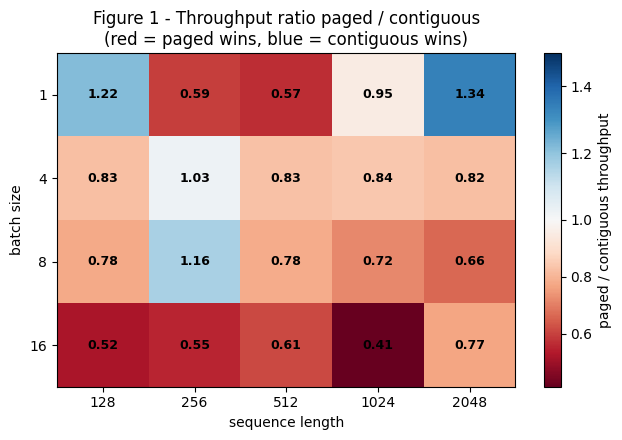

In [9]:
# Figure 1 — crossover heatmap. Diverging colormap centred at 1.0 so the
# paged-wins / contiguous-wins boundary is visually obvious (and readable in grayscale).
fig, ax = plt.subplots(figsize=(6.5, 4.5))
M = ratio.values
norm = TwoSlopeNorm(vmin=min(np.nanmin(M), 0.5), vcenter=1.0, vmax=max(np.nanmax(M), 1.5))
im = ax.imshow(M, cmap='RdBu', norm=norm, aspect='auto')

ax.set_xticks(range(len(ratio.columns)), ratio.columns)
ax.set_yticks(range(len(ratio.index)), ratio.index)
ax.set_xlabel('sequence length')
ax.set_ylabel('batch size')
ax.set_title('Figure 1 - Throughput ratio paged / contiguous\n(red = paged wins, blue = contiguous wins)')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center',
                    color='black', fontsize=9, fontweight='bold')
fig.colorbar(im, ax=ax, label='paged / contiguous throughput')
fig.tight_layout()
plt.show()

## 3. OOM and degraded runs

The spec treats OOM as a first-class outcome (if contiguous OOMs where paged survives, that is a strong
result). We surface any explicit OOM rows, plus a heuristic flag for TTFT spikes that signal memory
pressure / near-OOM.

In [5]:
oom = df[df['is_oom']]
print(f'Explicit OOM runs: {len(oom)}')
if len(oom):
    print(oom[['cache_type', 'seq_len', 'batch']].to_string(index=False))
else:
    print('  (none - every configuration completed on this hardware)')

# Heuristic: TTFT far above the per-cache-type median => prefill memory pressure / near-OOM.
med = ok.groupby('cache_type')['ttft_ms'].transform('median')
flag = ok[ok['ttft_ms'] > 8 * med].copy()
flag['ttft_vs_median'] = (ok['ttft_ms'] / med).round(1)
print('\nDegraded (TTFT > 8x cache-type median - likely near-OOM prefill):')
print(flag[['cache_type', 'seq_len', 'batch', 'ttft_ms', 'ttft_vs_median']].to_string(index=False)
      if len(flag) else '  (none)')

Explicit OOM runs: 0
  (none - every configuration completed on this hardware)

Degraded (TTFT > 8x cache-type median - likely near-OOM prefill):
cache_type  seq_len  batch  ttft_ms  ttft_vs_median
contiguous     2048     16   779.95           57.80
     paged     2048     16   996.22           30.70


## 4. Memory & fragmentation

Two different cost models. **Contiguous** reserves `max_seq_len` up front — its waste is *external*
(reserved-but-unused positions). **Paged** allocates blocks on demand — its waste is *internal*
(unused slots in the last block, bounded by `block_size - 1`). `frag_ratio` in the CSV is the
last-block waste for paged and reserved waste for contiguous.

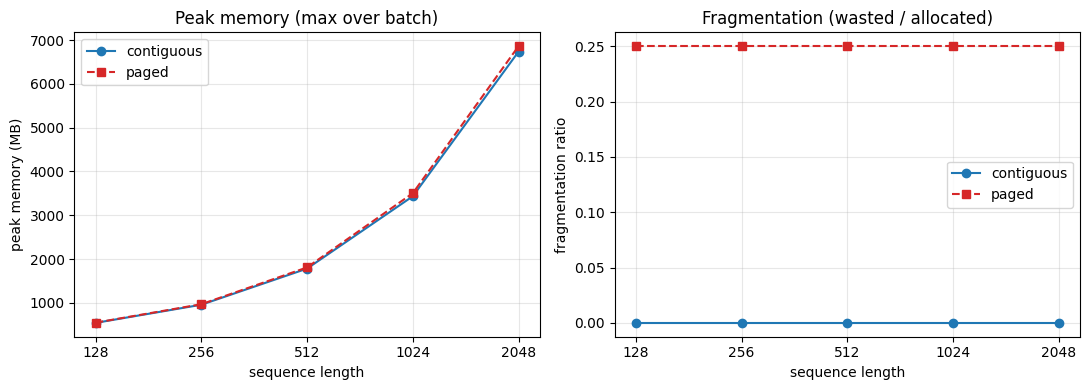

Mean frag_ratio:  contiguous=0.000   paged=0.250


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

# Peak process memory (model+activations dominate, so the two layouts look similar here -
# the structural difference shows up in frag_ratio, next panel).
for ct in ['contiguous', 'paged']:
    g = ok[ok.cache_type == ct].groupby('seq_len')['memory_mb'].max()
    a1.plot(g.index, g.values, label=ct, **STYLE[ct])
a1.set(xlabel='sequence length', ylabel='peak memory (MB)', title='Peak memory (max over batch)')
a1.set_xscale('log', base=2); a1.set_xticks(sorted(ok.seq_len.unique()))
a1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
a1.grid(True, alpha=0.3); a1.legend()

# Fragmentation by cache type (constant per design in this sweep).
for ct in ['contiguous', 'paged']:
    g = ok[ok.cache_type == ct].groupby('seq_len')['frag_ratio'].mean()
    a2.plot(g.index, g.values, label=ct, **STYLE[ct])
a2.set(xlabel='sequence length', ylabel='fragmentation ratio', title='Fragmentation (wasted / allocated)')
a2.set_xscale('log', base=2); a2.set_xticks(sorted(ok.seq_len.unique()))
a2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
a2.grid(True, alpha=0.3); a2.legend()
fig.tight_layout(); plt.show()

print('Mean frag_ratio:  ' + '   '.join(
    f'{ct}={ok[ok.cache_type==ct].frag_ratio.mean():.3f}' for ct in ['contiguous', 'paged']))

## 5. Insights summary

The cell below reads the numbers back out so the written takeaways always match the loaded CSV.

In [ ]:
print(f'Source: {CSV.name}\n' + '=' * 64)

# 1. TPOT flatness
p_b1 = ok[(ok.cache_type == 'paged') & (ok.batch == ok.batch.min())].sort_values('seq_len')
if len(p_b1) >= 2:
    growth = p_b1.tpot_ms.iloc[-1] / p_b1.tpot_ms.iloc[0]
    verdict = 'FLAT - no re-materialisation regression' if growth < 1.5 else 'GROWS with seq_len - check read path'
    print(f'1. Decode latency: paged TPOT {growth:.2f}x from seq {int(p_b1.seq_len.iloc[0])}'
          f' to {int(p_b1.seq_len.iloc[-1])} at batch {int(p_b1.batch.iloc[0])}  ->  {verdict}')

# 2. Crossover
if wins:
    bb, bs, br = max(wins, key=lambda t: t[2])
    print(f'2. Crossover: paged wins in {len(wins)}/{ratio.size} regimes; best is '
          f'seq={bs}, batch={bb} at {br:.2f}x. Paged favours LOW-to-MID batch, LONG context.')
else:
    print('2. Crossover: paged does not beat contiguous anywhere on throughput.')

# 3. H1
print(f'3. H1 (seq>=512 AND batch>=4): {"SUPPORTED" if h1_holds else "NOT SUPPORTED"} '
      f'(block mean ratio {h1_block.mean().mean():.2f}). '
      + ('' if h1_holds else 'Contiguous keeps the edge at high batch - paged wins at low batch instead.'))

# 4. Memory
paged_mem = ok[ok.cache_type == 'paged'].memory_mb.mean()
cont_mem = ok[ok.cache_type == 'contiguous'].memory_mb.mean()
print(f'4. Memory: peak process memory within {100*abs(paged_mem/cont_mem-1):.0f}% between layouts; '
      f'fragmentation is the real structural difference (paged '
      f'{ok[ok.cache_type=="paged"].frag_ratio.mean():.3f} vs contiguous '
      f'{ok[ok.cache_type=="contiguous"].frag_ratio.mean():.3f}).')

print('=' * 64)

Source: exp1_layout_comparison2.csv
1. Decode latency: paged TPOT 0.92x from seq 128 to 2048 at batch 1  ->  FLAT - no re-materialisation regression
2. Crossover: paged wins in 4/20 regimes; best is seq=2048, batch=1 at 1.34x. Paged favours LOW-to-MID batch, LONG context.
3. H1 (seq>=512 AND batch>=4): NOT SUPPORTED (block mean ratio 0.72). Contiguous keeps the edge at high batch - paged wins at low batch instead.
4. Memory: peak process memory within 2% between layouts; fragmentation is the real structural difference (paged 0.250 vs contiguous 0.000).
Next: Exp 2 sweeps block_size {8,16,32,64} to find the fragmentation/TPOT optimum.
